CONTOH 4.3

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

#DIKETAHUI
dTool = 10 #mm
rTool = dTool / 2 #mm

def tetaAvg(millingType, radImmersion):
    tetaStart1 = 0 #deg untuk up milling
    tetaStart2 = 180 - np.degrees(np.arccos(1-(2*radImmersion))) #deg untuk down milling
    tetaExit1 = round(np.degrees(np.arccos((rTool - (dTool * radImmersion))/rTool)))
    tetaExit2 = 180
    tetaAvg1 = (tetaStart1 + tetaExit1) / 2
    tetaAvg2 = (tetaStart2 + tetaExit2) / 2

    if millingType == 'up':
        return tetaAvg1
    elif millingType == 'down':
        return tetaAvg2
    elif millingType == 'slotting':
        tetaExit == 180
        return tetaAvg1

result_tetaAvg = tetaAvg('down', 0.2)


print(f'Hasil Teta Average adalah : {result_tetaAvg} deg')

Hasil Teta Average adalah : 153.43494882292202 deg


SLD UNTUK EXAMPLE 4.3

(0.0, 250.0)

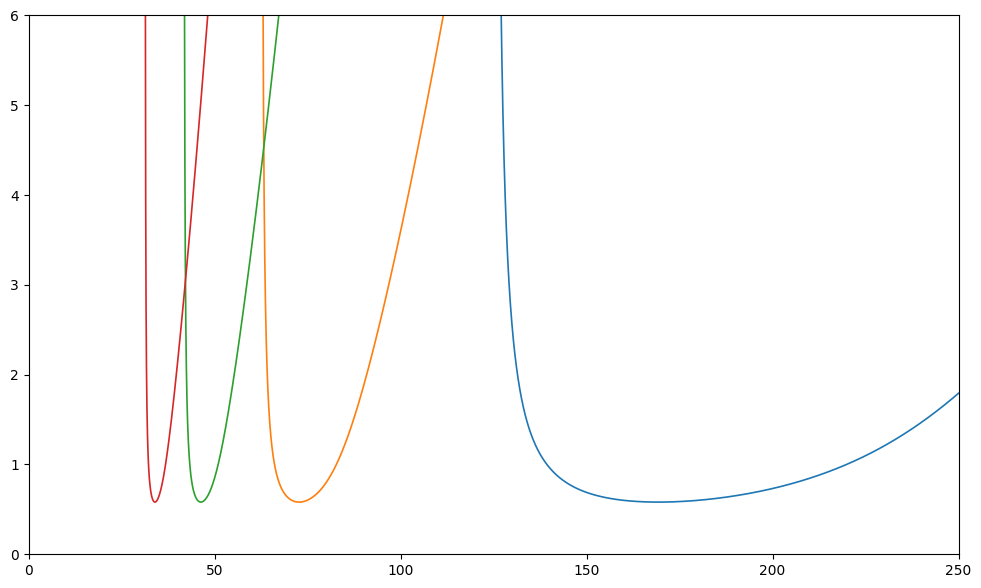

In [2]:
#Diketahui
fn = 500 #Hz
k = 8e3 #N/mm
zeta = 0.02
beta = 68 #deg
tooth = 4
ks = 750 #N/mm^2
ux = math.cos(math.radians(beta))
wn = 2 * np.pi * fn

tetaStart = 0
tetaExit = 180

Nt = (tetaExit - tetaStart) / (360/tooth)

#Menghitung Range Frekuensi
f_range = np.linspace(0, 1500, 150001)
omega   = 2 * np.pi * f_range   # rad/s

#Menghitung FRF (X/F)
def calculate_frf(w, mu, wn, zeta, k):
    """Hitung FRF: G(f) = (μ/k) / (1 - r² + 2jζr), r = ω/ωn"""
    r = w / wn
    return (mu / k) / (1 - r**2 + 2j * zeta * r)

frf = calculate_frf(omega, ux, wn, zeta, k)

#Menentukan Negative value dari Real Part
mask_unstable = frf.real < 0
f_valid = f_range[mask_unstable]
re_valid = frf.real[mask_unstable]
im_valid = frf.imag[mask_unstable]

epsilon = (2 * np.pi) - (2 * np.arctan2(re_valid, im_valid)) % (2 * np.pi)

blim_valid = -1 / (2 * ks * re_valid*Nt)

#Plot SLD
plt.figure(figsize=(12,7))

for N_lobe in range(4):
    n_speed = (f_valid/tooth) / (N_lobe + (epsilon / (2 * np.pi)))
    valid_idx = (n_speed > 0) & (blim_valid > 0)
    plt.plot(
        n_speed[valid_idx],
        blim_valid[valid_idx],
        linewidth = 1.2,
    )
plt.ylim(0, 6)
plt.xlim(0, 250)


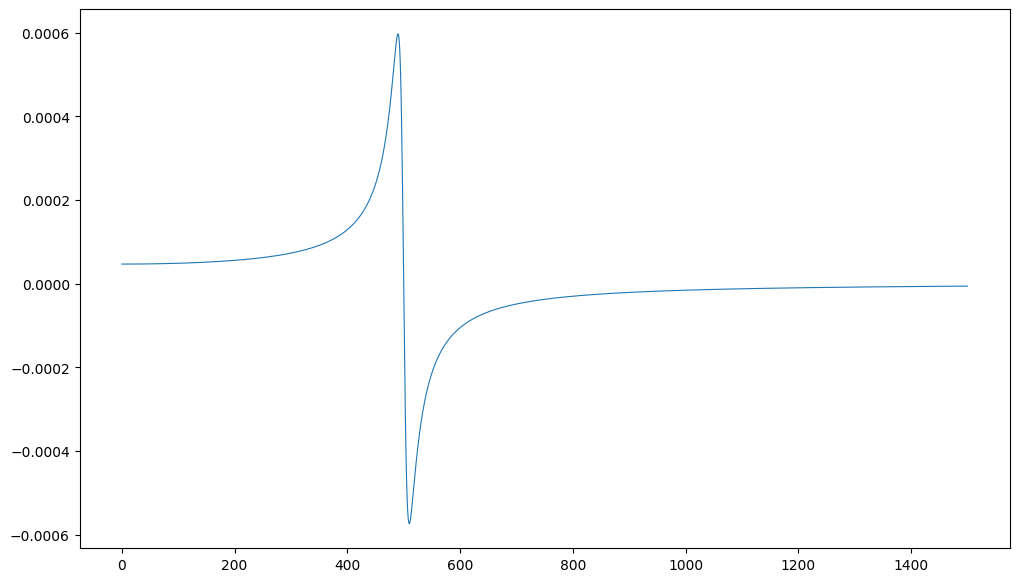

In [3]:
#Menghitung Range Frekuensi
f_range = np.linspace(0, 1500, 1501)
omega   = 2 * np.pi * f_range   # rad/s

#Menghitung FRF (X/F)
def calculate_frf(w, mu, wn, zeta, k):
    """Hitung FRF: G(f) = (μ/k) / (1 - r² + 2jζr), r = ω/ωn"""
    r = w / wn
    return (mu / k) / (1 - r**2 + 2j * zeta * r)

frf = calculate_frf(omega, ux, wn, zeta, k)

#Menentukan Negative value dari Real Part
mask_unstable = frf.real < 0
f_valid = f_range[mask_unstable]
re_valid = frf.real[mask_unstable]
im_valid = frf.imag[mask_unstable]

plt.figure(figsize=(12,7))

plt.plot(
    f_range,
    frf.real,
    linewidth = 0.8,
)


CONTOH 4.7

In [4]:
import math
import numpy as np
import matplotlib.pyplot as plt
# DIKETAHUI
dTool = 19 #mm
rTool = dTool / 2 #mm
def tetaAvg(millingType, radImmersion):
    if millingType == 'up':
        tetaStart = 0
        tetaExit = round(np.degrees(np.arccos((rTool - (dTool * radImmersion))/rTool)))
        tetaAvg_val = (tetaStart + tetaExit) / 2
        alpha = 90 + np.degrees(np.arccos(1-(2*radImmersion)))
    elif millingType == 'down':
        alpha = np.degrees(np.arccos(1-(2*radImmersion))) / 2
        tetaStart = 180 - np.degrees(np.arccos(1-(2*radImmersion)))
        tetaExit = 180
        tetaAvg_val = (tetaStart + tetaExit) / 2
    elif millingType == 'slotting':
        # FIX: Tambahan variabel yang kurang untuk slotting dan perbaikan typo
        tetaStart = 0
        tetaExit = 180
        tetaAvg_val = 90
        alpha = 90

    return alpha, tetaAvg_val, tetaStart

result_alpha, result_tetaAvg, result_tetaStart = tetaAvg('down', 0.2)
print(f'Hasil Alpha adalah : {result_alpha} deg')
print(f'Hasil Teta Average adalah : {result_tetaAvg} deg')
print(f'Teta Start adalah: {result_tetaStart}')

Hasil Alpha adalah : 26.565051177077994 deg
Hasil Teta Average adalah : 153.43494882292202 deg
Teta Start adalah: 126.86989764584402


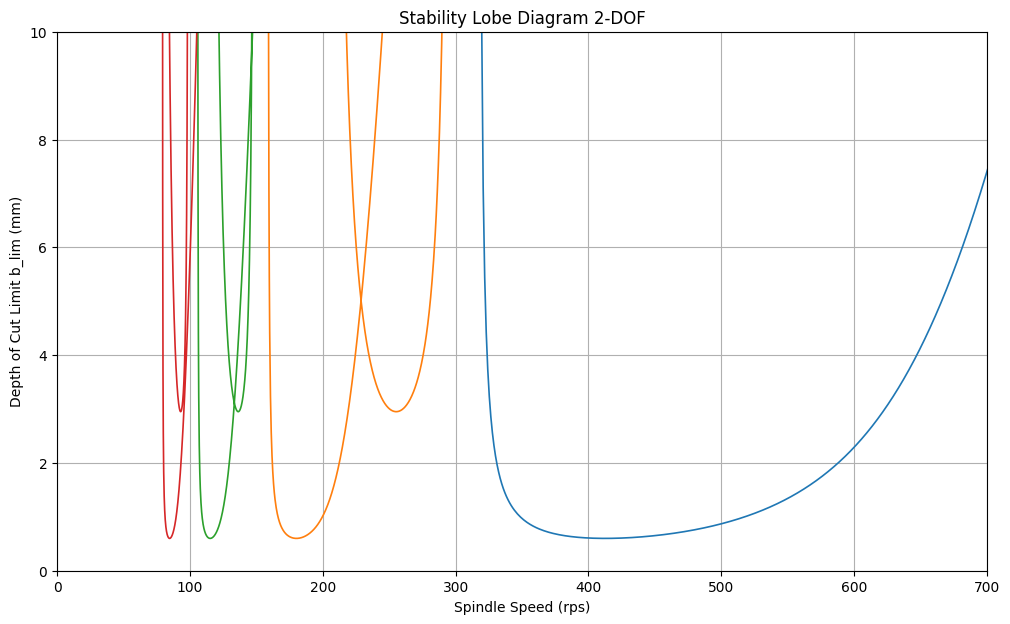

In [5]:
# Parameter Sistem
fnx = 900 # Hz
kx = 9e3 # N/mm
zeta_x = 0.02
wnx = 2 * np.pi * fnx
fny = 950 # Hz
ky = 1e4 #N/mm
zeta_y = 0.01
wny = 2 * np.pi * fny
tooth_1 = 3
ks = 2250 #N/mm^2
beta = 75 #deg
ax = 90 - result_alpha
# FIX: Konversi derajat ke radian sebelum masuk cos()
ax_rad = np.radians(ax)
beta_rad = np.radians(beta)
ux = np.cos(ax_rad + beta_rad) * np.cos(ax_rad)
uy = np.cos(beta_rad - ax_rad) * np.cos(ax_rad)
Nt = (180 - result_tetaStart) / (360 / tooth_1)
# Menghitung Range Frekuensi
f_range = np.linspace(0, 1500, 15000) # Dinaikkan resolusinya agar mulus seperti sebelumnya
omega   = 2 * np.pi * f_range
def calculate_frf(w, mu, wn, zeta, k):
    """Hitung FRF: G(f) = (μ/k) / (1 - r² + 2jζr), r = ω/ωn"""
    r = w / wn
    return (mu / k) / (1 - r**2 + 2j * zeta * r)
frfx = calculate_frf(omega, ux, wnx, zeta_x, kx)
frfy = calculate_frf(omega, uy, wny, zeta_y, ky)
# FIX: Cukup dijumlahkan secara linear
frf_combined = frfx + frfy
# FIX: Ganti `frf` dengan `frf_combined`
mask_unstable = frf_combined.real < 0
f_valid = f_range[mask_unstable]
re_valid = frf_combined.real[mask_unstable]
im_valid = frf_combined.imag[mask_unstable]
epsilon = (2 * np.pi) - (2 * np.arctan2(re_valid, im_valid)) % (2 * np.pi)
blim_valid = -1 / (2 * ks * re_valid * Nt)
# Plot SLD
plt.figure(figsize=(12,7))
for N_lobe in range(4):
    # FIX: Ganti `tooth` menjadi `tooth_1`
    n_speed = (f_valid / tooth_1)/ (N_lobe + (epsilon / (2 * np.pi)))
    valid_idx = (n_speed > 0) & (blim_valid > 0)
    plt.plot(
        n_speed[valid_idx],
        blim_valid[valid_idx],
        linewidth = 1.2,
    )
plt.ylim(0, 10)
plt.xlim(0, 700) # Dinamis menyesuaikan x
plt.xlabel('Spindle Speed (rps)')
plt.ylabel('Depth of Cut Limit b_lim (mm)')
plt.title('Stability Lobe Diagram 2-DOF')
plt.grid(True)
plt.show()